In [2]:
from sklearn.datasets import make_moons

In [5]:
moons_data, moons_label = make_moons(n_samples=10000, noise=0.4)

In [4]:
from sklearn.model_selection import train_test_split


In [6]:
X_train, X_test, y_train, y_test = train_test_split(moons_data, moons_label, test_size=0.2, random_state=42)

In [12]:
X_train.shape


(8000, 2)

In [13]:
y_train.shape

(8000,)

In [18]:
# Printing first Features
X_train[:5]

array([[ 0.29255327,  0.55849538],
       [ 0.61495774,  0.0245769 ],
       [ 0.99324609,  0.19710025],
       [ 1.13167315, -0.00554673],
       [-1.10057286,  0.80728997]])

In [17]:
# Printing first 5 Labels (Classifications)
y_train[:5]

array([0, 1, 1, 1, 0])

In [19]:
# Import Plotting library
import matplotlib.pyplot as plt



In [20]:
slice_of_array = X_train[:,0]

slice_of_array.shape

(8000,)

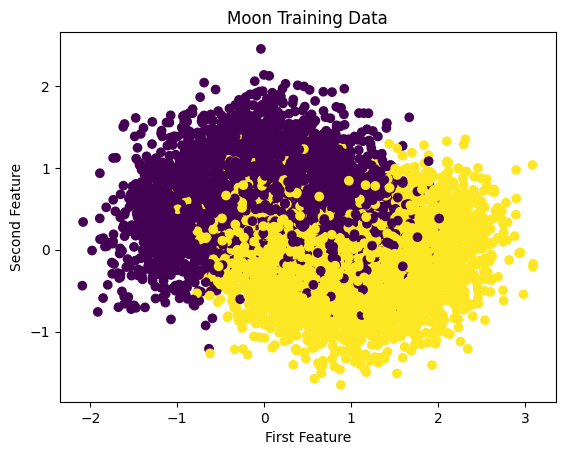

In [22]:
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.xlabel("First Feature")
plt.ylabel("Second Feature")
plt.title("Moon Training Data")
plt.show()

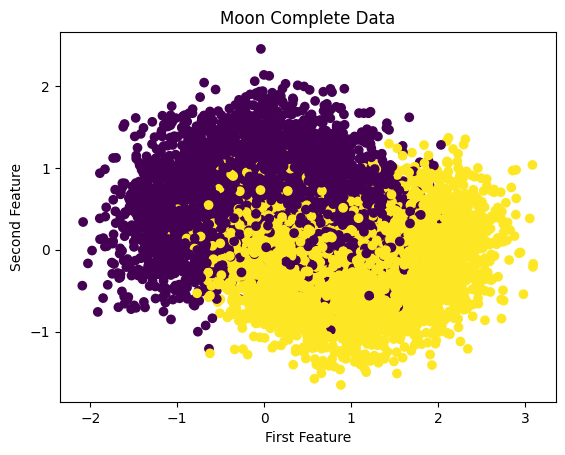

In [23]:
plt.scatter(moons_data[:, 0], moons_data[:, 1], c=moons_label)
plt.xlabel("First Feature")
plt.ylabel("Second Feature")
plt.title("Moon Complete Data")
plt.show()

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

In [37]:
param_grid = {
    'min_samples_leaf': list(range(2, 10))
    , 'max_leaf_nodes': list(range(2, 100))
    , 'max_depth': list(range(1,7))
}

dec_tree_clf = DecisionTreeClassifier()

In [38]:
grid_search_cv = GridSearchCV(dec_tree_clf, param_grid=param_grid, cv=3, n_jobs=4)

In [39]:
grid_search_cv.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [1, 2, ...], 'max_leaf_nodes': [2, 3, ...], 'min_samples_leaf': [2, 3, ...]}"
,scoring,None
,n_jobs,4
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [40]:
grid_search_cv.best_params_

{'max_depth': 6, 'max_leaf_nodes': 16, 'min_samples_leaf': 2}

In [41]:
best_estimator_dclf = grid_search_cv.best_estimator_

In [42]:
best_estimator_dclf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,16
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
y_predict = best_estimator_dclf.predict(X_test)

In [44]:
from sklearn.metrics import f1_score


In [45]:
f1_score_reached = f1_score(y_test, y_predict)

In [46]:
f1_score_reached

0.865234375

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict) # Return Value will be printed in notebook


0.862